In [55]:
import os
import glob
import re
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import LogNorm
from matplotlib.patches import Rectangle
from collections import defaultdict
from scipy.signal import find_peaks

os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

import numpy as np
import h5py

In [ ]:
# DUNE plot style
import sys; sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), "..", "utils"))
from dune_plot import apply_dune_style, dune_label
apply_dune_style()

## Waveform processing helpers (from Ar41 notebook)

Baseline correction, trap summation, and all constants are identical  
to `ar41_decay.ipynb` so that fprompt values are directly comparable.

In [56]:
def thd_correct(array):
    array_shape = np.shape(array)[-1]
    num_bins = int((array_shape // 25) + 1)
    indices = np.arange(0, num_bins) * 25
    start_indices, end_indices = indices[:-1], indices[1:]
    segment_range = np.arange(25)
    index_array = start_indices[:, None] + segment_range
    sliced_data = array[..., index_array]
    ranges = np.abs(np.ptp(sliced_data, axis=-1))
    means  = np.mean(sliced_data, axis=-1)
    mask_zero = (ranges != 0)
    ranges = np.where(mask_zero, ranges, np.nan)
    means  = np.where(mask_zero, means,  np.nan)
    smallest_ordering = np.argsort(ranges, axis=-1)
    sorted_means = np.take_along_axis(means, smallest_ordering, axis=-1)
    average_mean = np.nanmean(sorted_means[..., 1:3], axis=-1)
    fallback_mean = np.mean(array, axis=-1)
    average_mean = np.where(np.isnan(average_mean), fallback_mean, average_mean)
    return array - average_mean[..., None]


TRAP_NAME_MAP = [
    dict(adc=0, channels=[4,5,6,7,8,9],      name="ACL 2.01", tpc=0, z_side="-z", position="bottom"),
    dict(adc=0, channels=[10,11,12,13,14,15], name="ACL 2.02", tpc=0, z_side="-z", position="top"),
    dict(adc=0, channels=[20,21,22,23,24,25], name="ACL 2.03", tpc=0, z_side="+z", position="bottom"),
    dict(adc=0, channels=[26,27,28,29,30,31], name="ACL 2.04", tpc=0, z_side="+z", position="top"),
    dict(adc=0, channels=[52,53,54,55,56,57], name="ACL 2.05", tpc=1, z_side="-z", position="bottom"),
    dict(adc=0, channels=[58,59,60,61,62,63], name="ACL 2.06", tpc=1, z_side="-z", position="top"),
    dict(adc=0, channels=[36,37,38,39,40,41], name="ACL 2.07", tpc=1, z_side="+z", position="bottom"),
    dict(adc=0, channels=[42,43,44,45,46,47], name="ACL 2.08", tpc=1, z_side="+z", position="top"),
    dict(adc=1, channels=[4,5,6,7,8,9],      name="LCM 100-102", tpc=0, z_side="-z", position="bottom"),
    dict(adc=1, channels=[10,11,12,13,14,15], name="LCM 103-105", tpc=0, z_side="-z", position="top"),
    dict(adc=1, channels=[20,21,22,23,24,25], name="LCM 106-108", tpc=0, z_side="+z", position="bottom"),
    dict(adc=1, channels=[26,27,28,29,30,31], name="LCM 109-111", tpc=0, z_side="+z", position="top"),
    dict(adc=1, channels=[52,53,54,55,56,57], name="LCM 112-114", tpc=1, z_side="-z", position="bottom"),
    dict(adc=1, channels=[58,59,60,61,62,63], name="LCM 115-117", tpc=1, z_side="-z", position="top"),
    dict(adc=1, channels=[36,37,38,39,40,41], name="LCM 118-120", tpc=1, z_side="+z", position="bottom"),
    dict(adc=1, channels=[42,43,44,45,46,47], name="LCM 121-123", tpc=1, z_side="+z", position="top"),
    dict(adc=2, channels=[4,5,6,7,8,9],      name="ACL 2.09", tpc=2, z_side="-z", position="bottom"),
    dict(adc=2, channels=[10,11,12,13,14,15], name="ACL 2.10", tpc=2, z_side="-z", position="top"),
    dict(adc=2, channels=[20,21,22,23,24,25], name="ACL 2.11", tpc=2, z_side="+z", position="bottom"),
    dict(adc=2, channels=[26,27,28,29,30,31], name="ACL 2.12", tpc=2, z_side="+z", position="top"),
    dict(adc=2, channels=[52,53,54,55,56,57], name="ACL 2.13", tpc=3, z_side="-z", position="bottom"),
    dict(adc=2, channels=[58,59,60,61,62,63], name="ACL 2.14", tpc=3, z_side="-z", position="top"),
    dict(adc=2, channels=[36,37,38,39,40,41], name="ACL 2.15", tpc=3, z_side="+z", position="bottom"),
    dict(adc=2, channels=[42,43,44,45,46,47], name="ACL 2.16", tpc=3, z_side="+z", position="top"),
    dict(adc=3, channels=[20,21,22,23,24,25], name="LCM 124-126", tpc=2, z_side="-z", position="bottom"),
    dict(adc=3, channels=[26,27,28,29,30,31], name="LCM 127-129", tpc=2, z_side="-z", position="top"),
    dict(adc=3, channels=[4,5,6,7,8,9],      name="LCM 130-132", tpc=2, z_side="+z", position="bottom"),
    dict(adc=3, channels=[10,11,12,13,14,15], name="LCM 133-135", tpc=2, z_side="+z", position="top"),
    dict(adc=3, channels=[52,53,54,55,56,57], name="LCM 136-138", tpc=3, z_side="-z", position="bottom"),
    dict(adc=3, channels=[58,59,60,61,62,63], name="LCM 139-141", tpc=3, z_side="-z", position="top"),
    dict(adc=3, channels=[36,37,38,39,40,41], name="LCM 142-144", tpc=3, z_side="+z", position="bottom"),
    dict(adc=3, channels=[42,43,44,45,46,47], name="LCM 145-147", tpc=3, z_side="+z", position="top"),
    dict(adc=4, channels=[42,43,44,45,46,47], name="ACL 2.17",    tpc=4, z_side="-z", position="bottom"),
    dict(adc=4, channels=[36,37,38,39,40,41], name="ACL 2.18",    tpc=4, z_side="-z", position="top"),
    dict(adc=4, channels=[52,53,54,55,56,57], name="LCM 148-150", tpc=4, z_side="+z", position="bottom"),
    dict(adc=4, channels=[58,59,60,61,62,63], name="LCM 151-153", tpc=4, z_side="+z", position="top"),
    dict(adc=4, channels=[26,27,28,29,30,31], name="ACL 2.19",    tpc=5, z_side="-z", position="bottom"),
    dict(adc=4, channels=[20,21,22,23,24,25], name="ACL 2.20",    tpc=5, z_side="-z", position="top"),
    dict(adc=4, channels=[10,11,12,13,14,15], name="ACL 2.21",    tpc=5, z_side="+z", position="bottom"),
    dict(adc=4, channels=[4,5,6,7,8,9],      name="ACL 2.22",    tpc=5, z_side="+z", position="top"),
    dict(adc=5, channels=[42,43,44,45,46,57], name="LCM 154-156", tpc=4, z_side="-z", position="bottom"),
    dict(adc=5, channels=[58,59,60,61,62,63], name="ACL 2.23",    tpc=4, z_side="+z", position="bottom"),
    dict(adc=5, channels=[52,53,54,55,56,57], name="ACL 2.24",    tpc=4, z_side="+z", position="top"),
    dict(adc=5, channels=[36,37,38,39,40,41], name="LCM 157-159", tpc=4, z_side="+z", position="top"),
    dict(adc=5, channels=[26,27,28,29,30,31], name="LCM 160-162", tpc=5, z_side="-z", position="bottom"),
    dict(adc=5, channels=[20,21,22,23,24,25], name="LCM 163-165", tpc=5, z_side="-z", position="top"),
    dict(adc=5, channels=[10,11,12,13,14,15], name="LCM 166-168", tpc=5, z_side="+z", position="bottom"),
    dict(adc=5, channels=[4,5,6,7,8,9],      name="LCM 169-171", tpc=5, z_side="+z", position="top"),
    dict(adc=6, channels=[4,5,6,7,8,9],      name="ACL 2.25", tpc=6, z_side="-z", position="bottom"),
    dict(adc=6, channels=[10,11,12,13,14,15], name="ACL 2.26", tpc=6, z_side="-z", position="top"),
    dict(adc=6, channels=[20,21,22,23,24,25], name="ACL 2.27", tpc=6, z_side="+z", position="bottom"),
    dict(adc=6, channels=[26,27,28,29,30,31], name="ACL 2.28", tpc=6, z_side="+z", position="top"),
    dict(adc=6, channels=[52,53,54,55,56,57], name="ACL 2.29", tpc=7, z_side="-z", position="bottom"),
    dict(adc=6, channels=[58,59,60,61,62,63], name="ACL 2.30", tpc=7, z_side="-z", position="top"),
    dict(adc=6, channels=[36,37,38,39,40,41], name="ACL 2.31", tpc=7, z_side="+z", position="bottom"),
    dict(adc=6, channels=[42,43,44,45,46,47], name="ACL 2.32", tpc=7, z_side="+z", position="top"),
    dict(adc=7, channels=[4,5,6,7,8,9],      name="LCM 172-174", tpc=6, z_side="-z", position="bottom"),
    dict(adc=7, channels=[10,11,12,13,14,15], name="LCM 175-177", tpc=6, z_side="-z", position="top"),
    dict(adc=7, channels=[20,21,22,23,24,25], name="LCM 178-180", tpc=6, z_side="+z", position="bottom"),
    dict(adc=7, channels=[26,27,28,29,30,31], name="LCM 181-183", tpc=6, z_side="+z", position="top"),
    dict(adc=7, channels=[52,53,54,55,56,57], name="LCM 184-186", tpc=7, z_side="-z", position="bottom"),
    dict(adc=7, channels=[58,59,60,61,62,63], name="LCM 187-189", tpc=7, z_side="-z", position="top"),
    dict(adc=7, channels=[36,37,38,39,40,41], name="LCM 190-192", tpc=7, z_side="+z", position="bottom"),
    dict(adc=7, channels=[42,43,44,45,46,47], name="LCM 193-195", tpc=7, z_side="+z", position="top"),
]


def sum_to_traps(samples, trap_map):
    n_ev, _, _, n_t = samples.shape
    out = np.zeros((n_ev, len(trap_map), n_t), dtype=np.float64)
    for i, entry in enumerate(trap_map):
        out[:, i, :] = samples[:, entry["adc"], :, :][:, entry["channels"], :].sum(axis=1)
    return out


# Waveform processing constants — matching DTG.ipynb for DTG-on (978) data
CHUNK_SIZE              = 300
SAT_THRESHOLD           = 59000
PEAK_MAX_TICK           = 300    # reject events with total-sum peak at or after this tick
PILEUP_MIN_DISTANCE     = 100    # minimum separation (ticks) between peaks
PILEUP_MIN_REL_HEIGHT   = 0.5   # secondary peak must be >= this fraction of main peak

# ACL/LCM trap indices (TPC 6 excluded — sparking)
acl_idx = np.array([i for i, e in enumerate(TRAP_NAME_MAP) if e["name"].startswith("ACL") and e["tpc"] != 6])
lcm_idx = np.array([i for i, e in enumerate(TRAP_NAME_MAP) if e["name"].startswith("LCM") and e["tpc"] != 6])
acl_tpc = np.array([TRAP_NAME_MAP[i]["tpc"] for i in acl_idx])
lcm_tpc = np.array([TRAP_NAME_MAP[i]["tpc"] for i in lcm_idx])

print(f"ACL traps (excl. TPC 6): {len(acl_idx)},  LCM traps (excl. TPC 6): {len(lcm_idx)}")

ACL traps (excl. TPC 6): 28,  LCM traps (excl. TPC 6): 28


<cell_type>markdown</cell_type>## Step 1: Process all waveforms (light-only, full statistics)

Same pipeline as `DTG.ipynb` for DTG-on (run 978) data:  
chunk-based reading, baseline correction, trap summation,  
**dynamic** peak finding per trap, late-peak rejection (tick >= 300),  
pileup detection via scipy `find_peaks`.  

Every event x every trap = one entry. No charge matching yet.

In [57]:
FLOW_DIR = "/global/cfs/cdirs/dunepro/www/data/nd-production/2x2_run2/reflows/v0p2.PRELIMINARY/flow/source_dtg_bin2/two_trig_40us_period_500tick/hv_65kV_beamC_25uA/dtg_30min_thenDecay"
CSV_DIR  = "/global/cfs/cdirs/dune/users/lmlepin/cluster_outputs/DTG_ON_CL_eps_3_minsamp_1"

# Group CSV chunks by base HDF5 filename (needed later for charge matching)
csv_files = sorted(glob.glob(os.path.join(CSV_DIR, "*.csv")))
chunks_by_base = defaultdict(list)
for f in csv_files:
    base = os.path.basename(f).rsplit(".chunk_", 1)[0]
    chunks_by_base[base].append(f)

# Sort bases numerically by the _pNN_ part (not alphabetically)
def _part_number(fname):
    m = re.search(r'_p(\d+)_', fname)
    return int(m.group(1)) if m else 0

all_bases = sorted(chunks_by_base.keys(), key=_part_number)

# Select N evenly spaced files
N_FILES = 20
indices = np.linspace(0, len(all_bases) - 1, N_FILES, dtype=int)
selected_bases = [all_bases[i] for i in indices]

print(f"CSV bases available: {len(all_bases)}, selecting {N_FILES}:")
for i, b in zip(indices, selected_bases):
    print(f"  [{i:3d}] {b}  (p{_part_number(b)})")

CSV bases available: 50, selecting 20:
  [  0] mpd_run_run2data_rctl_978_p0_v0p2.FLOW.hdf5  (p0)
  [  2] mpd_run_run2data_rctl_978_p5_v0p2.FLOW.hdf5  (p5)
  [  5] mpd_run_run2data_rctl_978_p8_v0p2.FLOW.hdf5  (p8)
  [  7] mpd_run_run2data_rctl_978_p10_v0p2.FLOW.hdf5  (p10)
  [ 10] mpd_run_run2data_rctl_978_p15_v0p2.FLOW.hdf5  (p15)
  [ 12] mpd_run_run2data_rctl_978_p17_v0p2.FLOW.hdf5  (p17)
  [ 15] mpd_run_run2data_rctl_978_p21_v0p2.FLOW.hdf5  (p21)
  [ 18] mpd_run_run2data_rctl_978_p24_v0p2.FLOW.hdf5  (p24)
  [ 20] mpd_run_run2data_rctl_978_p26_v0p2.FLOW.hdf5  (p26)
  [ 23] mpd_run_run2data_rctl_978_p30_v0p2.FLOW.hdf5  (p30)
  [ 25] mpd_run_run2data_rctl_978_p33_v0p2.FLOW.hdf5  (p33)
  [ 28] mpd_run_run2data_rctl_978_p36_v0p2.FLOW.hdf5  (p36)
  [ 30] mpd_run_run2data_rctl_978_p38_v0p2.FLOW.hdf5  (p38)
  [ 33] mpd_run_run2data_rctl_978_p44_v0p2.FLOW.hdf5  (p44)
  [ 36] mpd_run_run2data_rctl_978_p48_v0p2.FLOW.hdf5  (p48)
  [ 38] mpd_run_run2data_rctl_978_p50_v0p2.FLOW.hdf5  (p50)
  [ 41]

In [58]:
MAX_EVENTS_PER_FILE = 1000  # Set to e.g. 1000 to cap events per file; None = all events


def process_file(path, chunk_size=CHUNK_SIZE, max_events=MAX_EVENTS_PER_FILE):
    """
    Process one HDF5 file in memory-safe chunks.
    Identical processing to DTG.ipynb for DTG-on (978) data:
    - Dynamic peak finding per trap (argmax)
    - Late-peak rejection (total-sum peak >= PEAK_MAX_TICK)
    - Fprompt windows centered on each trap's own peak
    - Pileup detection via scipy.signal.find_peaks
    """
    fp_acl, en_acl, np_acl = [], [], []
    fp_lcm, en_lcm, np_lcm = [], [], []
    ev_indices = []  # event index within file (= light_id for charge matching)

    with h5py.File(path, "r") as h:
        wvfm_data = h["/light/wvfm/data"]
        n_total = len(wvfm_data)
        if max_events is not None:
            n_total = min(n_total, max_events)

        for start in range(0, n_total, chunk_size):
            stop = min(start + chunk_size, n_total)
            n_chunk = stop - start

            raw = wvfm_data["samples"][start:stop]  # (chunk, 8, 64, 500)
            samples = thd_correct(raw.astype(np.float32)); del raw
            saturated = (samples >= SAT_THRESHOLD).any(axis=(-1, -2, -3))
            trap_wvfms = sum_to_traps(samples, TRAP_NAME_MAP).astype(np.float32); del samples
            # trap_wvfms: (n_chunk, n_traps, 500)
            n_traps = trap_wvfms.shape[1]
            n_t = trap_wvfms.shape[2]

            # Late-peak rejection: total-sum peak position
            total_wvfm = trap_wvfms.sum(axis=1)           # (n_chunk, 500)
            event_peak_tick = total_wvfm.argmax(axis=-1)   # (n_chunk,)
            late_peak = event_peak_tick >= PEAK_MAX_TICK
            del total_wvfm

            bad_event = saturated | late_peak

            # Dynamic fprompt: windows centered on each trap's own peak
            peak_idx = trap_wvfms.argmax(axis=-1)  # (n_chunk, n_traps)
            prompt_idx = np.clip(peak_idx[..., None] + np.arange(-5, 10),  0, n_t - 1)  # 15 ticks
            total_idx  = np.clip(peak_idx[..., None] + np.arange(-5, 195), 0, n_t - 1)  # 200 ticks
            fprompt_num = np.take_along_axis(trap_wvfms, prompt_idx, axis=-1).sum(axis=-1)
            fprompt_den = np.take_along_axis(trap_wvfms, total_idx,  axis=-1).sum(axis=-1)
            trap_fprompts  = fprompt_num / fprompt_den
            trap_integrals = trap_wvfms.sum(axis=-1)  # full 500-tick integral

            # Pileup detection per trap via scipy.signal.find_peaks
            trap_peak_heights = trap_wvfms.max(axis=-1)  # (n_chunk, n_traps)
            n_peaks_traps = np.ones((n_chunk, n_traps), dtype=np.int8)
            for ev in range(n_chunk):
                if bad_event[ev]:
                    continue
                for trap in range(n_traps):
                    threshold = PILEUP_MIN_REL_HEIGHT * trap_peak_heights[ev, trap]
                    peaks, _ = find_peaks(trap_wvfms[ev, trap],
                                          height=threshold,
                                          distance=PILEUP_MIN_DISTANCE)
                    n_peaks_traps[ev, trap] = len(peaks)
            del trap_wvfms

            good = ~bad_event
            fp_acl.append(trap_fprompts[good][:, acl_idx])
            en_acl.append(trap_integrals[good][:, acl_idx])
            np_acl.append(n_peaks_traps[good][:, acl_idx])
            fp_lcm.append(trap_fprompts[good][:, lcm_idx])
            en_lcm.append(trap_integrals[good][:, lcm_idx])
            np_lcm.append(n_peaks_traps[good][:, lcm_idx])

            # Track event indices for non-bad events
            chunk_indices = np.arange(start, stop)[good]
            ev_indices.append(chunk_indices)

    def cat(lst): return np.concatenate(lst, axis=0) if lst else np.array([]).reshape(0, 0)
    return {
        "fprompt_acl": cat(fp_acl), "energy_acl": cat(en_acl), "n_peaks_acl": cat(np_acl),
        "fprompt_lcm": cat(fp_lcm), "energy_lcm": cat(en_lcm), "n_peaks_lcm": cat(np_lcm),
        "event_indices": np.concatenate(ev_indices) if ev_indices else np.array([], dtype=int),
    }

In [41]:
# Process all selected files
results = {}  # base_name -> dict from process_file()

for base in selected_bases:
    path = os.path.join(FLOW_DIR, base)
    print(f"Processing {base} ...", end=" ", flush=True)
    results[base] = process_file(path)
    r = results[base]
    n_ev = r["fprompt_acl"].shape[0] if r["fprompt_acl"].ndim == 2 else 0
    print(f"done  — {n_ev:,} events (non-saturated)")

total_events = sum(r["fprompt_acl"].shape[0] for r in results.values()
                   if r["fprompt_acl"].ndim == 2)
print(f"\nTotal events across {len(results)} files: {total_events:,}")

Processing mpd_run_run2data_rctl_978_p0_v0p2.FLOW.hdf5 ... 

/tmp/ipykernel_1532804/2265004134.py:16: RuntimeWarning: Mean of empty slice
  average_mean = np.nanmean(sorted_means[..., 1:3], axis=-1)
/tmp/ipykernel_1532804/504061448.py:49: RuntimeWarning: divide by zero encountered in divide
  trap_fprompts  = fprompt_num / fprompt_den


done  — 582 events (non-saturated)
Processing mpd_run_run2data_rctl_978_p13_v0p2.FLOW.hdf5 ... done  — 612 events (non-saturated)
Processing mpd_run_run2data_rctl_978_p16_v0p2.FLOW.hdf5 ... done  — 598 events (non-saturated)
Processing mpd_run_run2data_rctl_978_p18_v0p2.FLOW.hdf5 ... done  — 587 events (non-saturated)
Processing mpd_run_run2data_rctl_978_p22_v0p2.FLOW.hdf5 ... done  — 624 events (non-saturated)
Processing mpd_run_run2data_rctl_978_p24_v0p2.FLOW.hdf5 ... done  — 602 events (non-saturated)
Processing mpd_run_run2data_rctl_978_p27_v0p2.FLOW.hdf5 ... done  — 578 events (non-saturated)
Processing mpd_run_run2data_rctl_978_p32_v0p2.FLOW.hdf5 ... done  — 622 events (non-saturated)
Processing mpd_run_run2data_rctl_978_p34_v0p2.FLOW.hdf5 ... done  — 613 events (non-saturated)
Processing mpd_run_run2data_rctl_978_p37_v0p2.FLOW.hdf5 ... done  — 620 events (non-saturated)
Processing mpd_run_run2data_rctl_978_p42_v0p2.FLOW.hdf5 ... done  — 593 events (non-saturated)
Processing mpd_

In [74]:
# save results to disk for later use
import pickle
# with open("DTG_charge_data.pkl", "wb") as f:
#     pickle.dump(results, f)

# read results back from disk (if needed)
with open("DTG_charge_data.pkl", "rb") as f:
    results = pickle.load(f)

## Step 2: Fprompt vs Energy — full statistics

Every event x every trap is an entry (same as Ar41 notebook).  
No charge matching needed — this is pure light.

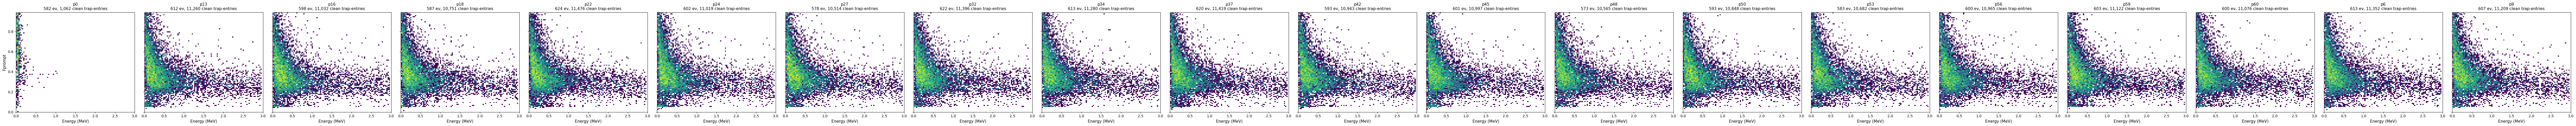

In [75]:
DETECTOR   = "lcm"    # "acl" or "lcm"
TPC_FILTER = None     # None = all TPCs, or int for single TPC

EN_BINS = np.arange(0, 3, 0.03)
FP_BINS = np.arange(0, 1, 0.01)

def _select(res, det, tpc_filter=None):
    """Return flat fp, en, npe arrays, optionally restricted to one TPC."""
    fp  = res[f"fprompt_{det}"]
    en  = res[f"energy_{det}"]
    npe = res[f"n_peaks_{det}"]
    tpc_arr = acl_tpc if det == "acl" else lcm_tpc
    if tpc_filter is not None:
        col = tpc_arr == tpc_filter
        fp, en, npe = fp[:, col], en[:, col], npe[:, col]
    return fp.ravel(), en.ravel(), npe.ravel()


def short_label(fname):
    m = re.search(r'_p(\d+)_', fname)
    return f"p{m.group(1)}" if m else fname[:20]


# Side-by-side fprompt vs energy for each file
n_files = len(results)
fig, axes = plt.subplots(1, n_files, figsize=(5 * n_files, 5), sharey=True, sharex=True)
if n_files == 1:
    axes = [axes]

for ax, (base, res) in zip(axes, results.items()):
    fp, en, npe = _select(res, DETECTOR, TPC_FILTER)
    en_mev = en / 147 * 0.004 / 4
    clean = np.isfinite(fp) & np.isfinite(en_mev) & (npe <= 2)
    n_ev = res["fprompt_acl"].shape[0] if res["fprompt_acl"].ndim == 2 else 0
    tpc_label = f" TPC {TPC_FILTER}" if TPC_FILTER is not None else ""
    ax.hist2d(en_mev[clean], fp[clean], bins=[EN_BINS, FP_BINS], norm=LogNorm())
    ax.set_title(f"{short_label(base)}{tpc_label}\n{n_ev:,} ev, {clean.sum():,} clean trap-entries",
                 fontsize=11)
    ax.set_xlabel("Energy (MeV)", fontsize=11)
    ax.set_xlim(0, 3)

axes[0].set_ylabel("Fprompt", fontsize=11)
plt.tight_layout()
plt.show()

Total trap-entries: 336,112
Clean (npe==1, finite): 115,464


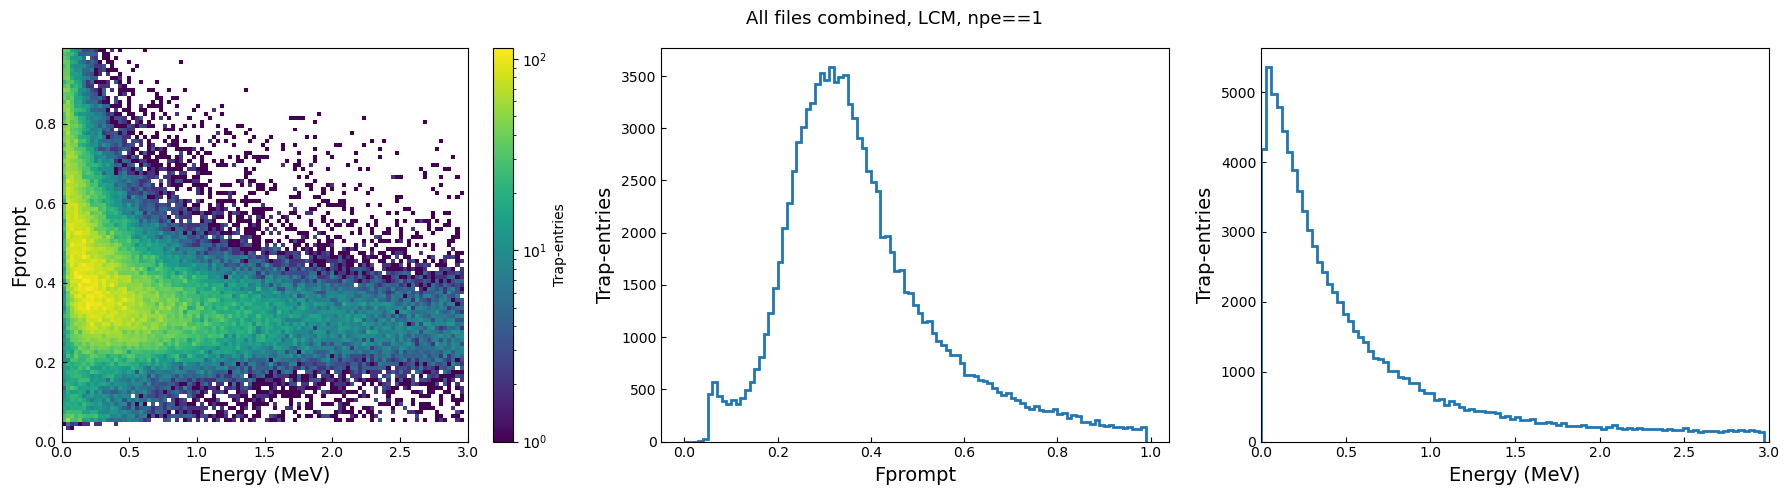

In [76]:
# Combined plot: all files merged
all_fp, all_en, all_npe = [], [], []
for res in results.values():
    fp, en, npe = _select(res, DETECTOR, TPC_FILTER)
    all_fp.append(fp); all_en.append(en); all_npe.append(npe)
all_fp  = np.concatenate(all_fp)
all_en  = np.concatenate(all_en)
all_npe = np.concatenate(all_npe)
all_en_mev = all_en / 147 * 0.004 / 4
clean = np.isfinite(all_fp) & np.isfinite(all_en_mev) & (all_npe == 1)

print(f"Total trap-entries: {len(all_fp):,}")
print(f"Clean (npe==1, finite): {clean.sum():,}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
h = ax.hist2d(all_en_mev[clean], all_fp[clean], bins=[EN_BINS, FP_BINS],
              norm=LogNorm(), cmap="viridis")
plt.colorbar(h[3], ax=ax, label="Trap-entries")
ax.set_xlabel("Energy (MeV)", fontsize=14)
ax.set_ylabel("Fprompt", fontsize=14)
ax.set_xlim(0, 3)
ax.tick_params(direction="in")

axes[1].hist(all_fp[clean], bins=FP_BINS, histtype="step", lw=2)
axes[1].set_xlabel("Fprompt", fontsize=14)
axes[1].set_ylabel("Trap-entries", fontsize=14)
axes[1].tick_params(direction="in")

axes[2].hist(all_en_mev[clean], bins=EN_BINS, histtype="step", lw=2)
axes[2].set_xlabel("Energy (MeV)", fontsize=14)
axes[2].set_ylabel("Trap-entries", fontsize=14)
axes[2].set_xlim(0, 3)
axes[2].tick_params(direction="in")

fig.suptitle(f"All files combined, {DETECTOR.upper()}, npe==1", fontsize=13)
plt.tight_layout()
plt.show()

## Define regions of interest

Using the same Ar-41 signal region as `ar41_decay.ipynb`.  
Adjust after looking at the 2D histogram above.

In [77]:
# Ar-41 signal region (same as ar41_decay.ipynb)
AR41_FP_MIN = 0.6
AR41_FP_MAX = 0.9
AR41_EN_MIN = 0.4   # MeV
AR41_EN_MAX = 1.0   # MeV

REGIONS = {
    "Ar41 signal": {"fp": (AR41_FP_MIN, AR41_FP_MAX), "en": (AR41_EN_MIN, AR41_EN_MAX)},
    "High fprompt":{"fp": (0.9, 1.0),                 "en": (AR41_EN_MIN, AR41_EN_MAX)},
    "Low fprompt": {"fp": (0.0, 0.6),                 "en": (AR41_EN_MIN, AR41_EN_MAX)},
    "High energy": {"fp": (0.0, 1.0),                 "en": (1.0, 3.0)},
}

REGION_COLORS = {
    "Ar41 signal":  "tab:blue",
    "High fprompt": "tab:red",
    "Low fprompt":  "tab:green",
    "High energy":  "tab:orange",
}


def in_region(fp, en_mev, region):
    """Boolean mask for trap-entries falling in a region."""
    fp_lo, fp_hi = region["fp"]
    en_lo, en_hi = region["en"]
    mask = np.isfinite(fp) & np.isfinite(en_mev)
    if fp_lo is not None: mask &= fp >= fp_lo
    if fp_hi is not None: mask &= fp < fp_hi
    if en_lo is not None: mask &= en_mev >= en_lo
    if en_hi is not None: mask &= en_mev < en_hi
    return mask


# Count trap-entries per region
print(f"Region counts (clean single-peak trap-entries, {DETECTOR.upper()}):")
for name, region in REGIONS.items():
    mask = in_region(all_fp, all_en_mev, region) & (all_npe == 1)
    print(f"  {name:20s}: {mask.sum():7,}")

Region counts (clean single-peak trap-entries, LCM):
  Ar41 signal         :     830
  High fprompt        :      19
  Low fprompt         :  24,821
  High energy         :  17,917


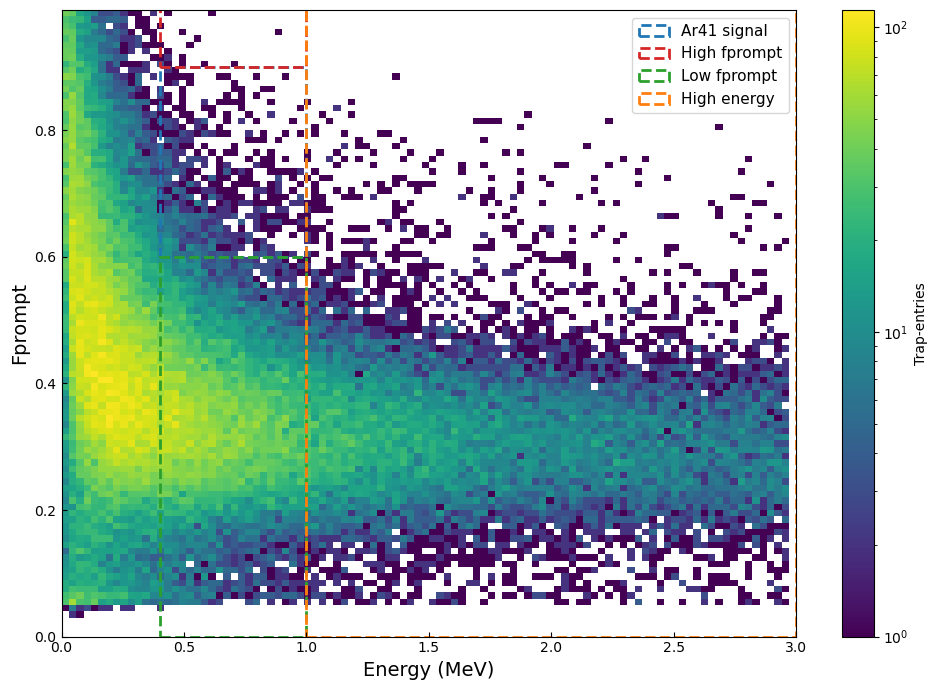

In [78]:
# Show regions overlaid on the combined 2D histogram
fig, ax = plt.subplots(figsize=(10, 7))
h = ax.hist2d(all_en_mev[clean], all_fp[clean], bins=[EN_BINS, FP_BINS],
              norm=LogNorm(), cmap="viridis")
plt.colorbar(h[3], ax=ax, label="Trap-entries")

for name, region in REGIONS.items():
    fp_lo, fp_hi = region["fp"]
    en_lo, en_hi = region["en"]
    fp_lo = fp_lo if fp_lo is not None else 0
    fp_hi = fp_hi if fp_hi is not None else 1
    en_lo = en_lo if en_lo is not None else 0
    en_hi = en_hi if en_hi is not None else 3
    rect = Rectangle((en_lo, fp_lo), en_hi - en_lo, fp_hi - fp_lo,
                      linewidth=2, edgecolor=REGION_COLORS[name],
                      facecolor="none", linestyle="--", label=name)
    ax.add_patch(rect)

ax.set_xlabel("Energy (MeV)", fontsize=14)
ax.set_ylabel("Fprompt", fontsize=14)
ax.set_xlim(0, 3)
ax.legend(fontsize=11, loc="upper right")
ax.tick_params(direction="in")
plt.tight_layout()
plt.show()

In [79]:
# Per-file counts in each region (time dependence)
print(f"Per-file region counts ({DETECTOR.upper()}, single-peak):")
print()
header = f"{'File':>8s}  {'N events':>8s}"
for name in REGIONS:
    header += f"  {name:>15s}"
print(header)

for base, res in results.items():
    fp, en, npe = _select(res, DETECTOR, TPC_FILTER)
    en_mev = en / 147 * 0.004 / 4
    n_ev = res["fprompt_acl"].shape[0] if res["fprompt_acl"].ndim == 2 else 0
    row = f"{short_label(base):>8s}  {n_ev:>8,}"
    for name, region in REGIONS.items():
        mask = in_region(fp, en_mev, region) & (npe == 1)
        row += f"  {mask.sum():>15,}"
    print(row)

Per-file region counts (LCM, single-peak):

    File  N events      Ar41 signal     High fprompt      Low fprompt      High energy
      p0       582                0                0               12                1
     p13       612               51                0            1,316              935
     p16       598               56                0            1,297              926
     p18       587               42                0            1,246              938
     p22       624               39                0            1,334              994
     p24       602               50                1            1,284              962
     p27       578               44                0            1,193              910
     p32       622               44                1            1,332              964
     p34       613               42                1            1,313              911
     p37       620               37                0            1,352              975

## Step 3: Charge matching — positions for events in each region

For each file, we know which *event indices* fall in each region  
(from the per-event, per-trap light arrays above).  
Now we load Leonardo's charge CSVs and match by `light_id` = event index.

In [88]:
MIN_CHARGE_HITS = 3  # minimum clustered charge hits per cluster

def find_event_indices_in_region(res, det, region):
    """
    Return the event indices (within the file) that have at least one trap-entry
    falling in the given region with n_peaks==1.

    Since the light arrays are (n_events, n_traps), an event is "in region" if
    ANY of its traps passes the cuts.
    """
    fp  = res[f"fprompt_{det}"]
    en  = res[f"energy_{det}"]
    npe = res[f"n_peaks_{det}"]
    en_mev = en / 147 * 0.004 / 4

    # Per-trap boolean mask: (n_events, n_traps)
    trap_in_region = in_region(fp, en_mev, region) & (npe == 1)
    # Event is in region if any trap qualifies
    event_in_region = trap_in_region.any(axis=1)  # (n_events,)
    return res["event_indices"][event_in_region]


def load_charge_for_file(base):
    """Load and concatenate charge CSV chunks for a given base file."""
    if base not in chunks_by_base:
        return None
    dfs = [pd.read_csv(f) for f in sorted(chunks_by_base[base])]
    return pd.concat(dfs, ignore_index=True)


def get_charge_centroids(csv_df, light_ids, min_hits=MIN_CHARGE_HITS):
    """
    For each (light_id, cluster_label) pair, compute the charge cluster centroid
    (if it has enough hits). Each cluster is a separate entry.
    """
    clustered = csv_df[(csv_df["cluster_label"] != -1) &
                       csv_df["light_id"].isin(light_ids)]
    if len(clustered) == 0:
        return pd.DataFrame()

    grouped = clustered.groupby(["light_id", "cluster_label"])
    records = []
    for (lid, clabel), group in grouped:
        if len(group) < min_hits:
            continue
        records.append({
            "light_id":      int(lid),
            "cluster_label": int(clabel),
            "n_charge_hits": len(group),
            "charge_x":      group["x"].mean(),
            "charge_y":      group["y"].mean(),
            "charge_z":      group["z"].mean(),
            "charge_E":      group["E"].sum(),
            "charge_Q":      group["Q"].sum(),
        })
    return pd.DataFrame(records)

In [89]:
# For each region, collect charge positions across all files
charge_by_region = {name: [] for name in REGIONS}

for base, res in results.items():
    csv_df = load_charge_for_file(base)
    if csv_df is None or len(csv_df) == 0:
        print(f"  {short_label(base)}: no charge CSV, skipping")
        continue

    for region_name, region in REGIONS.items():
        ev_idx = find_event_indices_in_region(res, DETECTOR, region)
        if len(ev_idx) == 0:
            continue

        centroids = get_charge_centroids(csv_df, set(ev_idx.tolist()))
        if len(centroids) > 0:
            centroids["file"] = base
            charge_by_region[region_name].append(centroids)

    n_ev = res["fprompt_acl"].shape[0] if res["fprompt_acl"].ndim == 2 else 0
    matched = {name: len(charge_by_region[name][-1]) if charge_by_region[name] and
               charge_by_region[name][-1]["file"].iloc[0] == base else 0
               for name in REGIONS}
    print(f"  {short_label(base)}: {n_ev} light events, charge matches: {matched}")

# Merge into DataFrames
charge_dfs = {}
for name in REGIONS:
    if charge_by_region[name]:
        charge_dfs[name] = pd.concat(charge_by_region[name], ignore_index=True)
    else:
        charge_dfs[name] = pd.DataFrame()

print("\nCharge-matched events per region:")
for name, df in charge_dfs.items():
    print(f"  {name:20s}: {len(df)} events with charge")

  p0: 582 light events, charge matches: {'Ar41 signal': 0, 'High fprompt': 0, 'Low fprompt': 50, 'High energy': 3}
  p13: 612 light events, charge matches: {'Ar41 signal': 2620, 'High fprompt': 0, 'Low fprompt': 31834, 'High energy': 26334}
  p16: 598 light events, charge matches: {'Ar41 signal': 0, 'High fprompt': 0, 'Low fprompt': 0, 'High energy': 0}
  p18: 587 light events, charge matches: {'Ar41 signal': 2110, 'High fprompt': 0, 'Low fprompt': 25170, 'High energy': 22411}
  p22: 624 light events, charge matches: {'Ar41 signal': 2254, 'High fprompt': 0, 'Low fprompt': 33047, 'High energy': 29377}
  p24: 602 light events, charge matches: {'Ar41 signal': 0, 'High fprompt': 0, 'Low fprompt': 0, 'High energy': 0}
  p27: 578 light events, charge matches: {'Ar41 signal': 0, 'High fprompt': 0, 'Low fprompt': 0, 'High energy': 0}
  p32: 622 light events, charge matches: {'Ar41 signal': 2506, 'High fprompt': 43, 'Low fprompt': 31063, 'High energy': 26098}
  p34: 613 light events, charge mat

## Fprompt vs Energy: charge-matched vs no charge match

Split events into those that have any charge cluster (>= MIN_CHARGE_HITS)  
and those that don't. Compare their fprompt-energy distributions.

Charge-matched events:   54,247 clean trap-entries
No charge match events:  61,217 clean trap-entries


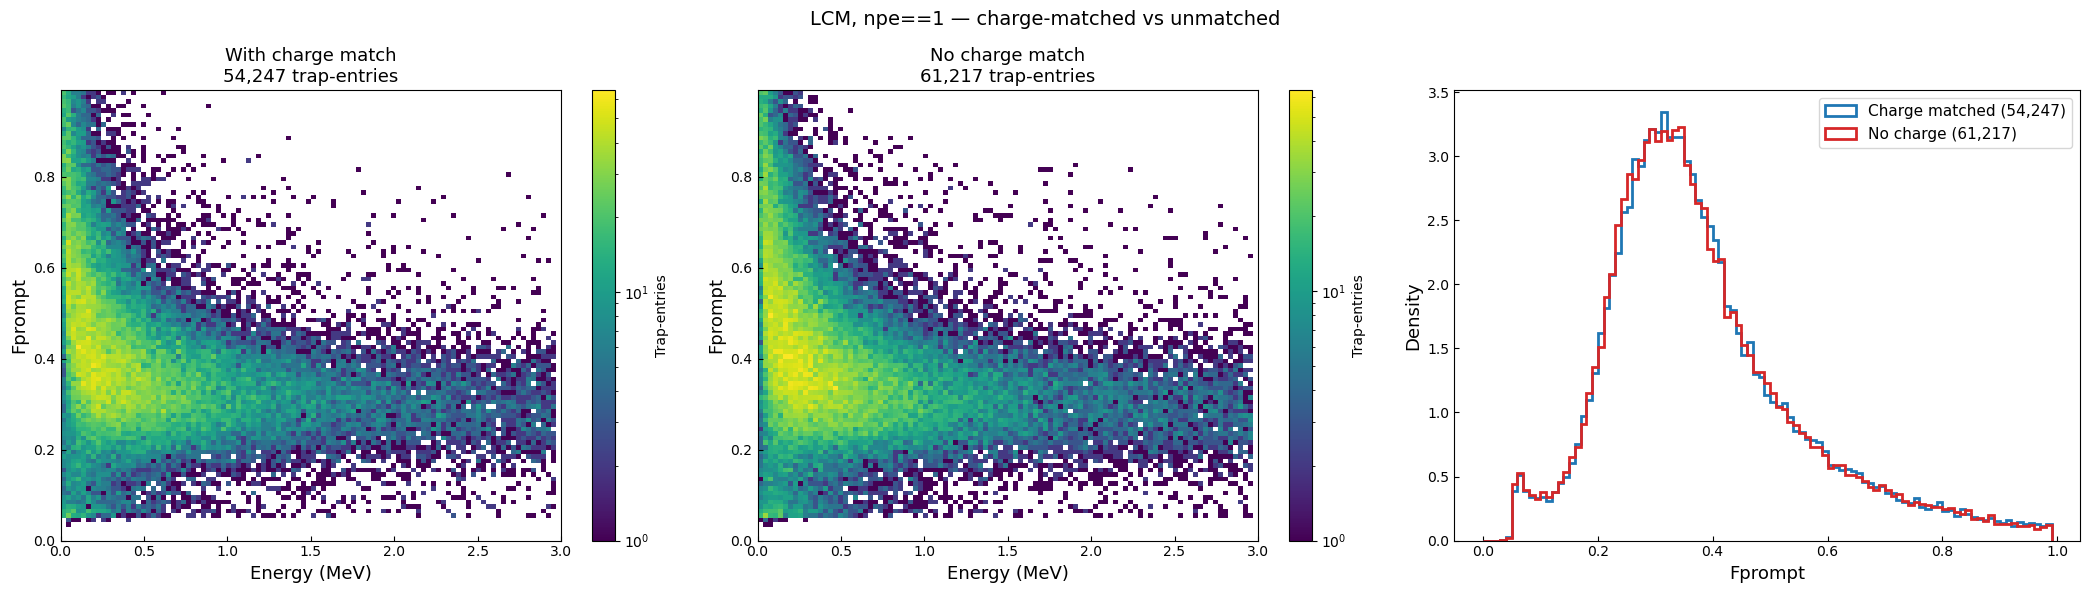

In [90]:
# Build per-event charge-match flag for each file, then collect
# trap-level fprompt/energy arrays split by matched vs unmatched.
fp_matched, en_matched, npe_matched = [], [], []
fp_unmatched, en_unmatched, npe_unmatched = [], [], []

for base, res in results.items():
    ev_idx = res["event_indices"]
    n_ev = len(ev_idx)
    if n_ev == 0:
        continue

    # Load charge CSV for this file
    csv_df = load_charge_for_file(base)
    if csv_df is not None and len(csv_df) > 0:
        # Find which light_ids have at least MIN_CHARGE_HITS clustered hits
        clustered = csv_df[csv_df["cluster_label"] != -1]
        hits_per_event = clustered.groupby("light_id").size()
        matched_lids = set(hits_per_event[hits_per_event >= MIN_CHARGE_HITS].index.astype(int))
    else:
        matched_lids = set()

    # Boolean mask over the event axis of the result arrays
    has_charge = np.array([int(idx) in matched_lids for idx in ev_idx])

    fp  = res[f"fprompt_{DETECTOR}"]
    en  = res[f"energy_{DETECTOR}"]
    npe = res[f"n_peaks_{DETECTOR}"]

    fp_matched.append(fp[has_charge]);    en_matched.append(en[has_charge]);    npe_matched.append(npe[has_charge])
    fp_unmatched.append(fp[~has_charge]); en_unmatched.append(en[~has_charge]); npe_unmatched.append(npe[~has_charge])

def _cat(lst):
    return np.concatenate(lst, axis=0) if lst else np.array([]).reshape(0, 0)

fp_m  = _cat(fp_matched).ravel();   en_m  = _cat(en_matched).ravel();   npe_m  = _cat(npe_matched).ravel()
fp_u  = _cat(fp_unmatched).ravel(); en_u  = _cat(en_unmatched).ravel(); npe_u  = _cat(npe_unmatched).ravel()
en_m_mev = en_m / 147 * 0.004 / 4
en_u_mev = en_u / 147 * 0.004 / 4
clean_m = np.isfinite(fp_m) & np.isfinite(en_m_mev) & (npe_m == 1)
clean_u = np.isfinite(fp_u) & np.isfinite(en_u_mev) & (npe_u == 1)

print(f"Charge-matched events:   {clean_m.sum():,} clean trap-entries")
print(f"No charge match events:  {clean_u.sum():,} clean trap-entries")

# Side-by-side 2D histograms
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

ax = axes[0]
if clean_m.sum() > 0:
    h = ax.hist2d(en_m_mev[clean_m], fp_m[clean_m], bins=[EN_BINS, FP_BINS], norm=LogNorm(), cmap="viridis")
    plt.colorbar(h[3], ax=ax, label="Trap-entries")
ax.set_title(f"With charge match\n{clean_m.sum():,} trap-entries", fontsize=13)
ax.set_xlabel("Energy (MeV)", fontsize=13)
ax.set_ylabel("Fprompt", fontsize=13)
ax.set_xlim(0, 3)
ax.tick_params(direction="in")

ax = axes[1]
if clean_u.sum() > 0:
    h = ax.hist2d(en_u_mev[clean_u], fp_u[clean_u], bins=[EN_BINS, FP_BINS], norm=LogNorm(), cmap="viridis")
    plt.colorbar(h[3], ax=ax, label="Trap-entries")
ax.set_title(f"No charge match\n{clean_u.sum():,} trap-entries", fontsize=13)
ax.set_xlabel("Energy (MeV)", fontsize=13)
ax.set_ylabel("Fprompt", fontsize=13)
ax.set_xlim(0, 3)
ax.tick_params(direction="in")

# Fprompt 1D comparison
ax = axes[2]
if clean_m.sum() > 0:
    ax.hist(fp_m[clean_m], bins=FP_BINS, histtype="step", lw=2, color="tab:blue",
            label=f"Charge matched ({clean_m.sum():,})", density=True)
if clean_u.sum() > 0:
    ax.hist(fp_u[clean_u], bins=FP_BINS, histtype="step", lw=2, color="tab:red",
            label=f"No charge ({clean_u.sum():,})", density=True)
ax.set_xlabel("Fprompt", fontsize=13)
ax.set_ylabel("Density", fontsize=13)
ax.legend(fontsize=11)
ax.tick_params(direction="in")

fig.suptitle(f"{DETECTOR.upper()}, npe==1 — charge-matched vs unmatched", fontsize=14)
plt.tight_layout()
plt.show()

## Charge positions by region

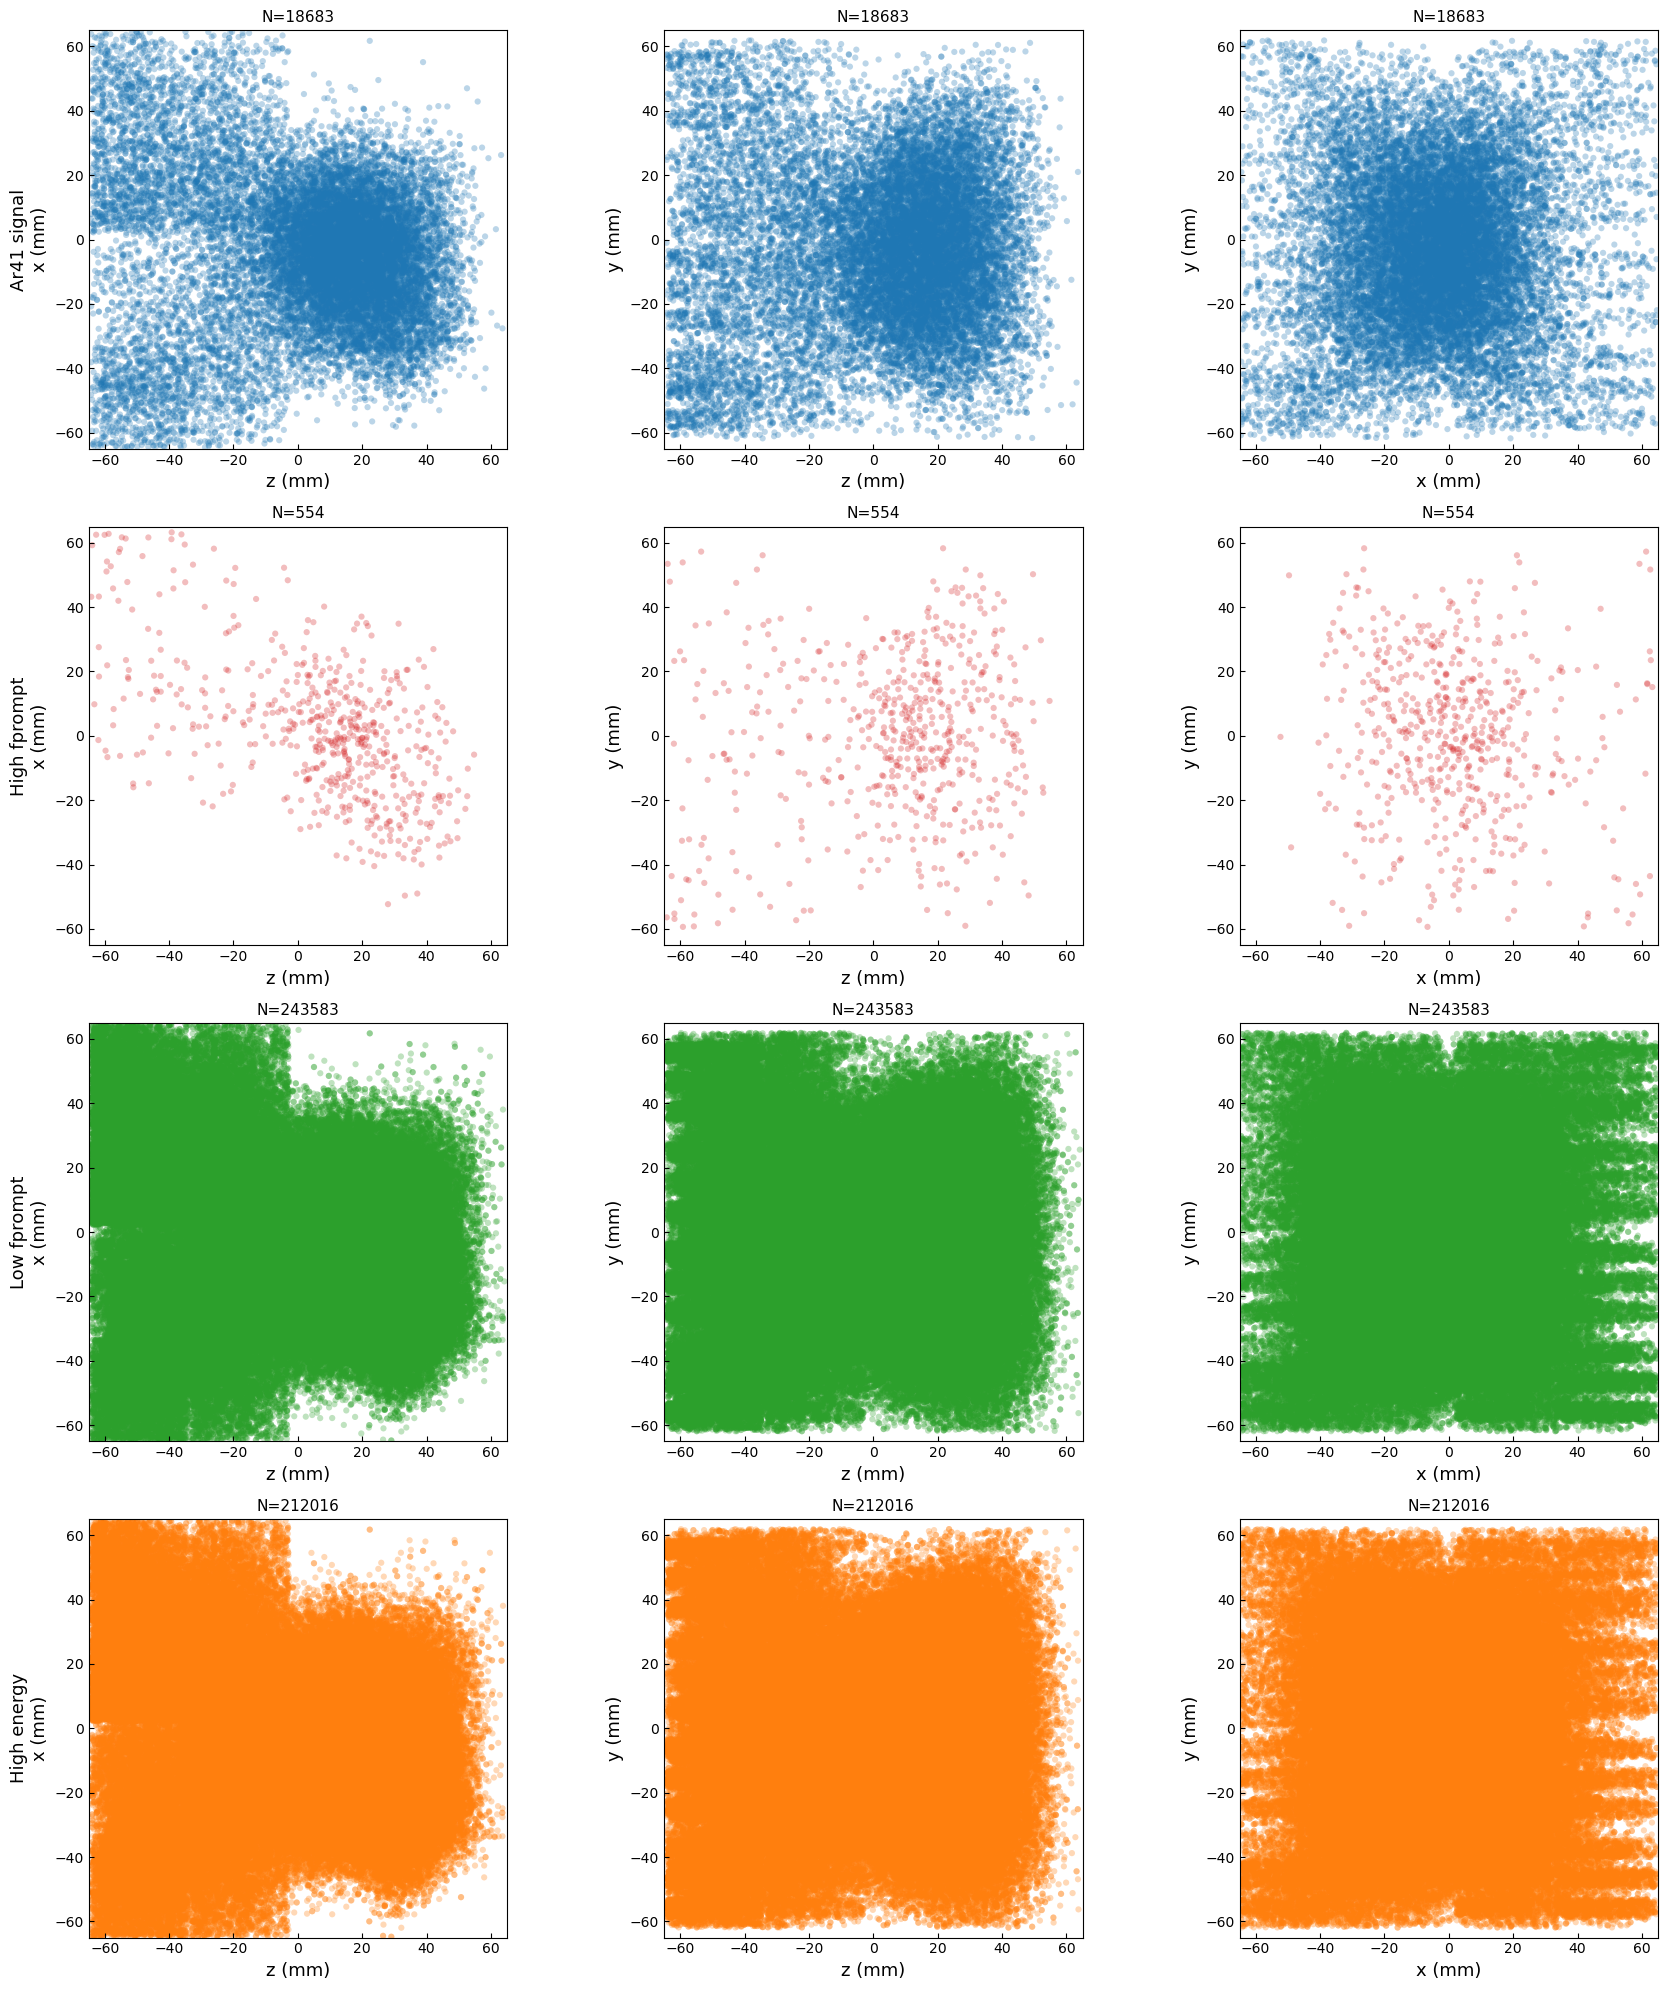

In [87]:
projections = [("charge_z", "charge_x", "z (mm)", "x (mm)"),
               ("charge_z", "charge_y", "z (mm)", "y (mm)"),
               ("charge_x", "charge_y", "x (mm)", "y (mm)")]

regions_to_plot = [name for name in REGIONS if len(charge_dfs.get(name, [])) > 0]

if not regions_to_plot:
    print("No charge-matched events in any region.")
else:
    # Individual panels per region
    fig, axes = plt.subplots(len(regions_to_plot), len(projections),
                             figsize=(6 * len(projections), 5 * len(regions_to_plot)),
                             squeeze=False)

    for i, region_name in enumerate(regions_to_plot):
        df = charge_dfs[region_name]
        color = REGION_COLORS[region_name]

        for j, (xc, yc, xl, yl) in enumerate(projections):
            ax = axes[i, j]
            ax.scatter(df[xc], df[yc], s=20, c=color, alpha=0.3, edgecolors="none")
            ax.set_xlabel(xl, fontsize=13)
            ax.set_ylabel(yl, fontsize=13)
            ax.tick_params(direction="in")
            ax.set_xlim(-65, 65)
            ax.set_ylim(-65, 65)
            ax.set_aspect("equal")
            if j == 0:
                ax.set_ylabel(f"{region_name}\n{yl}", fontsize=13)
            ax.set_title(f"N={len(df)}", fontsize=11)

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_1532804/1365133935.py:17: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/global/homes/m/mnuland/.conda/envs/myenv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


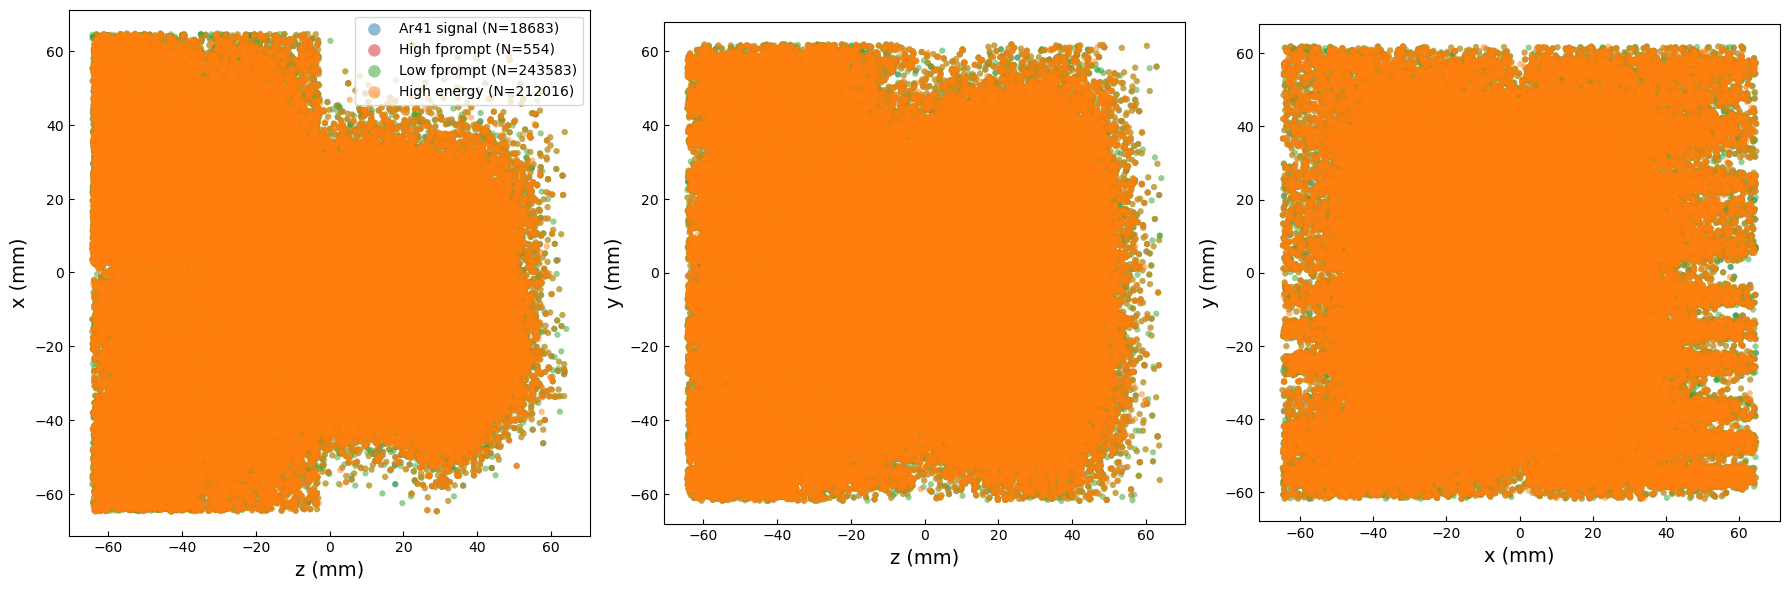

In [83]:
# All regions overlaid
if regions_to_plot:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    for region_name in regions_to_plot:
        df = charge_dfs[region_name]
        color = REGION_COLORS[region_name]
        for j, (xc, yc, xl, yl) in enumerate(projections):
            axes[j].scatter(df[xc], df[yc], s=20, c=color, alpha=0.5,
                            edgecolors="none", label=f"{region_name} (N={len(df)})")
            axes[j].set_xlabel(xl, fontsize=14)
            axes[j].set_ylabel(yl, fontsize=14)
            axes[j].tick_params(direction="in")
            axes[j].set_aspect("equal")

    axes[0].legend(fontsize=10, markerscale=2)
    plt.tight_layout()
    plt.show()

## Cross-checks

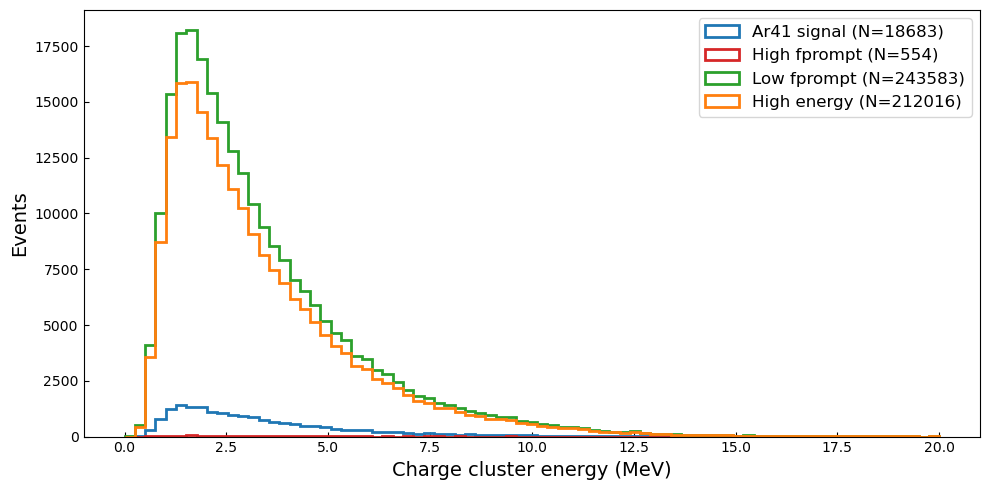

In [84]:
# Charge energy distributions by region
if regions_to_plot:
    fig, ax = plt.subplots(figsize=(10, 5))
    bins_E = np.linspace(0, 20, 80)

    for region_name in regions_to_plot:
        df = charge_dfs[region_name]
        ax.hist(df["charge_E"], bins=bins_E, histtype="step", lw=2,
                color=REGION_COLORS[region_name],
                label=f"{region_name} (N={len(df)})")

    ax.set_xlabel("Charge cluster energy (MeV)", fontsize=14)
    ax.set_ylabel("Events", fontsize=14)
    ax.legend(fontsize=12)
    ax.tick_params(direction="in")
    plt.tight_layout()
    plt.show()

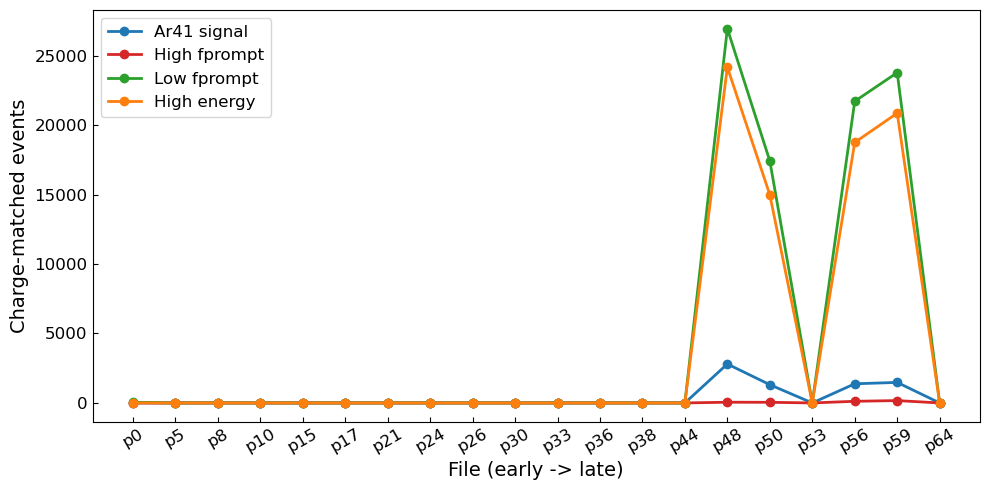

In [85]:
# Per-file time trend: charge-matched events per region
if regions_to_plot:
    fig, ax = plt.subplots(figsize=(10, 5))
    labels_ordered = [short_label(b) for b in selected_bases]

    for region_name in regions_to_plot:
        df = charge_dfs[region_name]
        if len(df) == 0:
            continue
        df["file_label"] = df["file"].map(lambda b: short_label(b))
        counts = df.groupby("file_label").size().reindex(labels_ordered, fill_value=0)
        ax.plot(counts.index, counts.values, marker="o", lw=2,
                color=REGION_COLORS[region_name], label=region_name)

    ax.set_xlabel("File (early -> late)", fontsize=14)
    ax.set_ylabel("Charge-matched events", fontsize=14)
    ax.legend(fontsize=12)
    ax.tick_params(direction="in", labelsize=12)
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

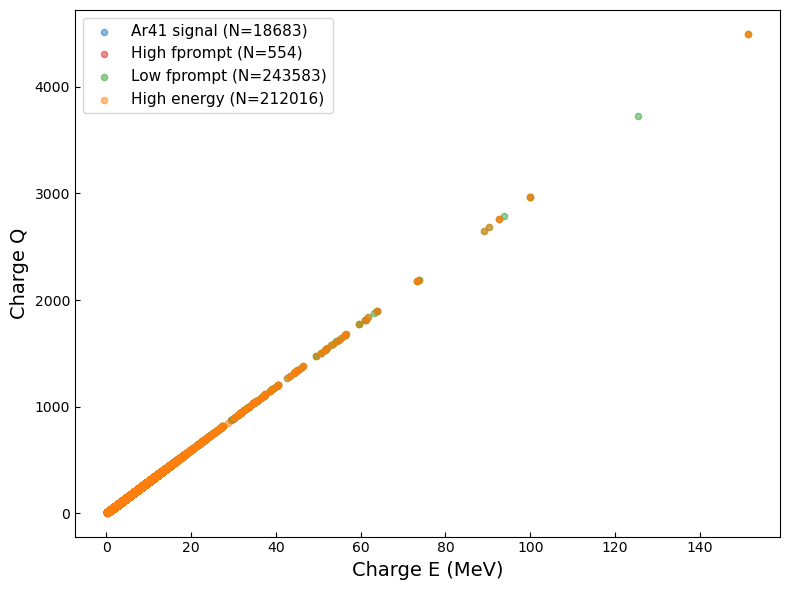

In [86]:
# Charge Q vs charge E by region
if regions_to_plot:
    fig, ax = plt.subplots(figsize=(8, 6))
    for region_name in regions_to_plot:
        df = charge_dfs[region_name]
        ax.scatter(df["charge_E"], df["charge_Q"], s=20, alpha=0.5,
                   c=REGION_COLORS[region_name],
                   label=f"{region_name} (N={len(df)})")

    ax.set_xlabel("Charge E (MeV)", fontsize=14)
    ax.set_ylabel("Charge Q", fontsize=14)
    ax.legend(fontsize=11)
    ax.tick_params(direction="in")
    plt.tight_layout()
    plt.show()